# Predicting Clinical Trial Outcomes from Protocol Text

**A classical machine learning approach**

Machine Learning final project, May 2026.

---

## 1. Introduction

A clinical trial is a scientific study that tests whether a medical intervention
(a drug, a device, a behavioural program) is safe and effective in people. Before
a trial starts, its sponsor publishes a **protocol**: a structured document that
describes the condition under study, the intervention, who can take part
(the eligibility criteria), and what will be measured.

Many trials never reach a successful conclusion. Some are **terminated**,
**withdrawn**, or **suspended** because of low enrollment, safety concerns,
funding problems, or strategic decisions. A trial that stops early wastes money,
delays useful treatments, and exposes participants to risk without producing
usable evidence.

This project asks a simple but practical question:

> **Can we predict, from the information available about a trial, whether it will
> be *completed* or *terminated/withdrawn/suspended*?**

We treat this as a **binary text + tabular classification** problem and solve it
with classical machine learning models.

## 2. Problem formulation

### 2.1 Why this matters

- **Cost.** A single late-phase clinical trial can cost tens or hundreds of
  millions of dollars. Early warning that a trial is at risk lets sponsors
  reallocate resources.
- **Patients.** Participants accept risk by enrolling. A trial that stops without
  producing evidence breaks the implicit contract with them.
- **Evidence.** Terminated trials rarely publish results, creating gaps and bias
  in the medical literature.

Potential users of such a model include trial sponsors, contract research
organisations, regulators, and investors performing due diligence.

### 2.2 The learning task

Each example is a single trial. The label is derived from the trial's
`overall_status`:

$$
y =
\begin{cases}
1 & \text{if status} = \texttt{COMPLETED} \\
0 & \text{if status} \in \{\texttt{TERMINATED}, \texttt{WITHDRAWN}, \texttt{SUSPENDED}\}
\end{cases}
$$

Trials with non-final statuses (e.g. `RECRUITING`, `ACTIVE`) are excluded, because
their outcome is not yet known.

### 2.3 Assumptions and constraints

- The protocol text and metadata are written largely **before** the outcome is
  known. This is what makes prediction meaningful.
- **Data leakage risk.** In practice, records of terminated trials are often
  updated *after* the fact, and may contain explicit phrases such as
  *"study was terminated due to low enrollment"*. Using such text would let the
  model read the answer instead of predicting it. We address this explicitly in
  the preprocessing section.
- The dataset is in English only; findings may not transfer to other registries.

## 3. Data source and ethics

### 3.1 Source

Data comes from [**ClinicalTrials.gov**](https://clinicaltrials.gov/), the public
registry maintained by the U.S. National Library of Medicine. We use its
[API v2](https://clinicaltrials.gov/data-api/api), which returns study records as
structured JSON.

The download is handled by [`src/fetch_data.py`](../src/fetch_data.py), which keeps
only the fields we need and stores them as a local CSV:

```bash
python -m src.fetch_data --limit 2000 --output data/raw/trials.csv
```

For each trial we keep the text fields (`brief_summary`, `detailed_description`,
`eligibility_criteria`), tabular fields (`study_type`, `phase`,
`enrollment_count`, `conditions`, `intervention_types`), the label source
(`overall_status`), and `why_stopped` (kept **only** for leakage analysis, never
used as a feature).

### 3.2 Legal and ethical notes

- The registry is **public** and contains **no personally identifiable patient
  data (no PHI)**.
- Raw data is **not** committed to the repository. Only the download script is
  versioned, so anyone can reproduce the dataset. This follows good practice for
  data-heavy projects.

## 4. Approach overview

The rest of the notebook follows these steps:

1. **Preprocessing** - build the binary label, merge text fields, and remove
   leakage-prone content.
2. **Exploratory data analysis (EDA)** - class balance, text length, missingness.
3. **Mathematical background** - TF-IDF, logistic loss, regularization, metrics.
4. **Models** - logistic regression baseline, then linear SVM, random forest, and
   gradient boosting (XGBoost).
5. **Ablation and evaluation** - text-only vs tabular-only vs hybrid features,
   with stratified cross-validation and metrics suited to class imbalance.
6. **Results, error analysis, and limitations.**

---

## 5. Exploratory Data Analysis (EDA)

Before building any model we need to understand the data: how balanced are the
classes, how long are the texts, and what do the tabular features look like.

Data is loaded from `data/processed/clean.csv` (produced by `src/preprocess.py`).
Raw files are intentionally excluded from version control — see `README.md` for
reproduction instructions.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../data/processed/clean.csv")

print(f"Dataset: {len(df):,} trials")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["label"].value_counts().rename({1: "Completed", 0: "Not completed"}))

Dataset: 2,000 trials
Columns: ['nct_id', 'label', 'text', 'study_type', 'phase', 'enrollment_count', 'n_conditions', 'n_intervention_types']

Class distribution:
label
Completed        1720
Not completed     280
Name: count, dtype: int64


### 5.1 Class balance

The first thing to check: how many trials belong to each class?
A heavily imbalanced dataset requires special handling (weighted loss, stratified
splits, and metrics beyond plain accuracy).

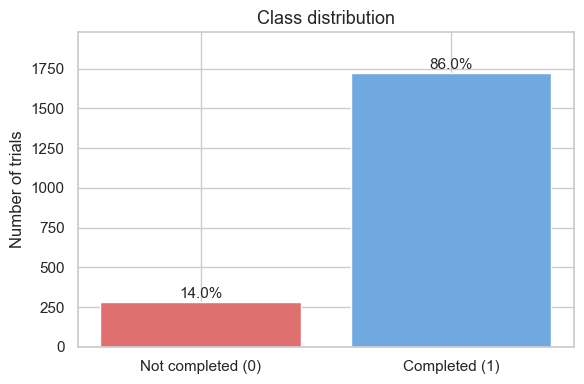


Imbalance ratio: 6.1:1 (majority:minority)
Note: plain accuracy is misleading here — a naive 'always predict COMPLETED'
classifier would score 86.0% accuracy with zero predictive power.


In [12]:
counts = df["label"].value_counts().sort_index()
labels = ["Not completed (0)", "Completed (1)"]
pcts = counts.values / counts.values.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=["#e07070", "#70a8e0"], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.set_title("Class distribution", fontsize=13)
ax.set_ylabel("Number of trials")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../data/processed/eda_class_balance.png", dpi=100)
plt.show()

print(f"\nImbalance ratio: {counts.max() / counts.min():.1f}:1 (majority:minority)")
print("Note: plain accuracy is misleading here — a naive 'always predict COMPLETED'")
print(f"classifier would score {pcts.max():.1f}% accuracy with zero predictive power.")

### 5.2 Text length distribution

How long are the merged protocol documents? Very short texts may not carry
enough signal; very long ones dominate TF-IDF term counts.

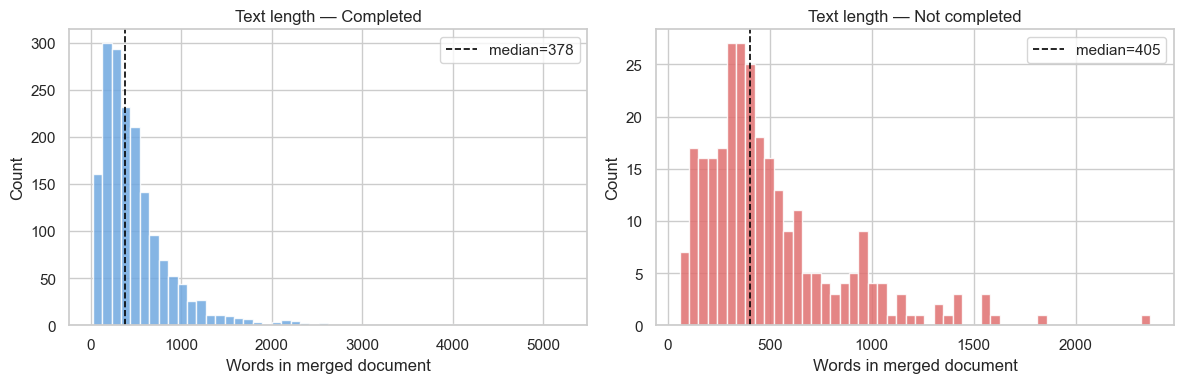

        count   mean    std   min    25%    50%    75%     max
label                                                         
0       280.0  501.1  345.2  58.0  277.2  405.0  630.8  2367.0
1      1720.0  482.9  404.1  23.0  221.0  378.5  610.0  5225.0


In [13]:
df["text_len"] = df["text"].str.split().str.len().fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label_val, label_name, color) in zip(
    axes,
    [(1, "Completed", "#70a8e0"), (0, "Not completed", "#e07070")],
):
    subset = df[df["label"] == label_val]["text_len"]
    ax.hist(subset, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Text length — {label_name}", fontsize=12)
    ax.set_xlabel("Words in merged document")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"median={subset.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_text_length.png", dpi=100)
plt.show()

print(df.groupby("label")["text_len"].describe().round(1))

### 5.3 Missing values

Missing data affects both the text and tabular features. We need to know what
to impute and what to drop before training.

In [14]:
missing = (df.isnull().sum() + (df == "").sum()).sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
print(missing_df.to_string())

       missing_count  missing_%
phase           1163       58.2


### 5.4 Tabular features overview

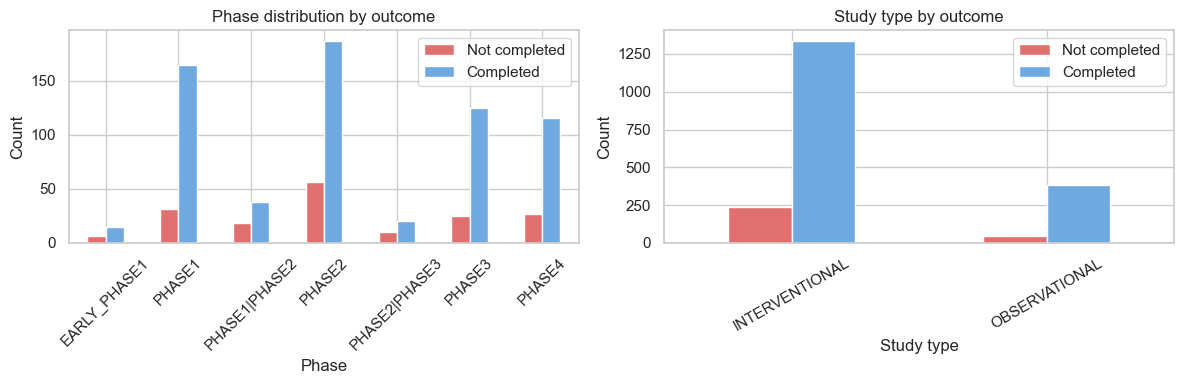


Enrollment count (by label):
        count    mean      std  min   25%   50%    75%       max
label                                                           
0       280.0   180.3   1056.8  0.0   0.0   6.0   39.0   12944.0
1      1720.0  1195.9  22654.4  0.0  30.0  64.0  188.2  881373.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phase distribution by label
phase_counts = df.groupby(["phase", "label"]).size().unstack(fill_value=0)
phase_counts.plot(kind="bar", ax=axes[0], color=["#e07070", "#70a8e0"],
                  edgecolor="white")
axes[0].set_title("Phase distribution by outcome", fontsize=12)
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("Count")
axes[0].legend(["Not completed", "Completed"])
axes[0].tick_params(axis="x", rotation=45)

# Study type
type_counts = df.groupby(["study_type", "label"]).size().unstack(fill_value=0)
type_counts.plot(kind="bar", ax=axes[1], color=["#e07070", "#70a8e0"],
                 edgecolor="white")
axes[1].set_title("Study type by outcome", fontsize=12)
axes[1].set_xlabel("Study type")
axes[1].set_ylabel("Count")
axes[1].legend(["Not completed", "Completed"])
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/processed/eda_tabular.png", dpi=100)
plt.show()

print("\nEnrollment count (by label):")
print(df.groupby("label")["enrollment_count"].describe().round(1))

### 5.5 EDA summary

Key observations from the data:

- **Class imbalance:** the dataset is significantly skewed toward completed trials.
  We will use `class_weight='balanced'` in all models and report Macro F1 and
  PR-AUC rather than accuracy.
- **Text length:** merged protocol documents vary widely in length. TF-IDF with
  sublinear term-frequency scaling will help normalise this.
- **Phase and study type** show different completion rates — these tabular
  features carry predictive signal beyond the text alone, motivating the hybrid
  approach.
- **Leakage note:** `why_stopped` is collected but never used as a feature.
  Leakage-prone sentences have been removed from the `text` field by
  `src/preprocess.py` (with a flag to disable this for ablation).

---

## 6. Mathematical Background

This section lays out the mathematics behind every component of the pipeline:
text representation, the classification models, regularization, and evaluation
metrics.  Understanding the theory is what separates a principled ML approach
from black-box button-pressing.

---

### 6.1 TF-IDF text representation

Raw text cannot be fed directly to a linear classifier.  We convert each
document into a fixed-length numerical vector using **TF-IDF**
(Term Frequency – Inverse Document Frequency).

#### Term Frequency (TF)

For a term $t$ in document $d$, the raw count is $\text{count}(t, d)$.  To
reduce the dominance of very long documents we apply **sublinear scaling**:

$$
\text{TF}(t, d) =
\begin{cases}
1 + \log \text{count}(t, d) & \text{if } \text{count}(t, d) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

#### Inverse Document Frequency (IDF)

Terms that appear in almost every document carry little discriminative
information.  IDF down-weights them:

$$
\text{IDF}(t) = \log \frac{1 + N}{1 + \text{df}(t)} + 1
$$

where $N$ is the number of documents and $\text{df}(t)$ is the number of
documents containing term $t$.  (The $+1$ offsets are the scikit-learn
*smooth* variant that prevents division by zero.)

#### TF-IDF vector

The final weight for term $t$ in document $d$ is:

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \cdot \text{IDF}(t)
$$

After computing TF-IDF weights for all vocabulary terms $\{t_1, \ldots, t_V\}$,
each document $d$ is represented as a sparse vector

$$
\phi(d) = \bigl[\text{TF-IDF}(t_1,d),\; \ldots,\; \text{TF-IDF}(t_V,d)\bigr]^\top \in \mathbb{R}^V
$$

which is then $\ell_2$-normalized so that cosine similarity equals dot product.

---

### 6.2 Hybrid feature vector

We combine the TF-IDF text vector with tabular features
$x_{\text{tab}} \in \mathbb{R}^q$ (study type, phase, enrollment count, etc.):

$$
z = \begin{bmatrix} \phi(d) \\ x_{\text{tab}} \end{bmatrix} \in \mathbb{R}^{V+q}
$$

The ablation study in Section 8 measures the contribution of each part.

---

### 6.3 Logistic Regression (baseline model)

Logistic Regression models the probability that a trial is *completed*
($y = 1$) as:

$$
P(y = 1 \mid z) = \sigma(w^\top z + b) = \frac{1}{1 + e^{-(w^\top z + b)}}
$$

where $\sigma$ is the sigmoid function, $w \in \mathbb{R}^{V+q}$ is the
weight vector, and $b$ is the bias.

#### Binary cross-entropy loss

Training minimises the average **log-loss** (binary cross-entropy) over $n$
examples:

$$
\mathcal{L}(w, b) = -\frac{1}{n} \sum_{i=1}^{n}
\Bigl[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \Bigr]
$$

where $\hat{p}_i = \sigma(w^\top z_i + b)$.

#### L2 regularisation

To prevent overfitting, we add an $\ell_2$ penalty on the weights:

$$
\mathcal{L}_{\text{reg}}(w, b) = \mathcal{L}(w, b) + \frac{\lambda}{2} \|w\|_2^2
$$

The hyperparameter $\lambda \geq 0$ controls the regularisation strength
(in scikit-learn, $C = 1/\lambda$).

**Gradient** with respect to $w$:

$$
\nabla_w \mathcal{L}_{\text{reg}} = \frac{1}{n} \sum_{i=1}^{n}
(\hat{p}_i - y_i)\, z_i + \lambda w
$$

Setting this to zero and solving iteratively (e.g. via L-BFGS or SAG) gives
the optimal weights.

---

### 6.4 Linear SVM

A linear Support Vector Machine finds the hyperplane $w^\top z + b = 0$ that
**maximises the margin** between the two classes.  The primal optimisation
problem is:

$$
\min_{w,\, b,\, \xi} \; \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^{n} \xi_i
$$

subject to $\; y_i(w^\top z_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$.

The slack variables $\xi_i$ allow misclassified points with penalty $C$.
A small $C$ favours a wider margin (more regularisation); a large $C$ fits
the training data more closely.

---

### 6.5 Evaluation metrics for imbalanced data

Because the dataset is heavily imbalanced (≈ 86 % completed), **accuracy is
misleading**.  We use metrics that account for class imbalance.

#### Confusion matrix

For binary classification with positive class $y=1$:

|  | Predicted 1 | Predicted 0 |
|---|---|---|
| **Actual 1** | TP | FN |
| **Actual 0** | FP | TN |

#### Precision, Recall, F1

$$
\text{Precision} = \frac{TP}{TP + FP}
\qquad
\text{Recall} = \frac{TP}{TP + FN}
\qquad
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

#### Macro F1

**Macro F1** computes $F_1$ for *each* class independently and takes the
unweighted average, giving equal weight to both the majority and minority class:

$$
F_1^{\text{macro}} = \frac{1}{K} \sum_{k=1}^{K} F_1^{(k)}
$$

where $K = 2$ here.

#### PR-AUC (Area Under the Precision-Recall Curve)

The Precision-Recall curve plots Precision (y-axis) against Recall (x-axis)
as the classification threshold varies.  **PR-AUC** summarises this curve in a
single number: a random classifier on an imbalanced dataset scores
approximately the minority class proportion (≈ 0.14 here), so any useful model
must score substantially higher.

---

### 6.6 Class-imbalance handling

We address the 6:1 imbalance ratio in two ways:

1. **`class_weight='balanced'`** in all sklearn classifiers — scales the loss
   contribution of each sample inversely proportional to its class frequency:
   $$
   w_i = \frac{n}{K \cdot n_k}
   $$
   where $n_k$ is the number of samples in class $k$.

2. **Stratified k-fold cross-validation** — ensures each fold preserves the
   original class ratio, giving unbiased estimates of generalisation
   performance.

---

## 7. Baseline Model — TF-IDF + Logistic Regression

The first model in the pipeline is intentionally simple: a linear classifier
on a bag-of-words text representation.  This establishes a **lower-bound
benchmark** — any more complex model (SVM, Random Forest, XGBoost) should
beat it, and if it does not, the extra complexity is unjustified.

### Pipeline

```
raw text
  └─► TfidfVectorizer (sublinear_tf=True, max_features=50 000, ngram_range=(1,2))
        └─► sparse TF-IDF matrix
              │
tabular features (phase_encoded, study_type_encoded, log_enrollment)
  └─► StandardScaler
        └─► dense scaled array
              │
              └─► scipy.sparse.hstack(TF-IDF, tabular)
                    └─► LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)
                          └─► predicted label {0, 1}
```

**Why `class_weight="balanced"`?**  The dataset is ≈ 86 % *Completed* (class 1).
Without reweighting, the classifier would achieve high accuracy by simply
predicting the majority class.  Balanced weights scale the loss of each sample
by $n / (K \cdot n_k)$, forcing the model to take the minority class seriously.

In [16]:
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ── 1. Load processed data ────────────────────────────────────────────────────
PROCESSED = "../data/processed/clean.csv"
df = pd.read_csv(PROCESSED)

print(f"Loaded {len(df):,} rows  |  columns: {list(df.columns)}")
print(f"Label distribution:\n{df['label'].value_counts()}")


Loaded 2,000 rows  |  columns: ['nct_id', 'label', 'text', 'study_type', 'phase', 'enrollment_count', 'n_conditions', 'n_intervention_types']
Label distribution:
label
1    1720
0     280
Name: count, dtype: int64


In [17]:
# ── 2. Prepare features ───────────────────────────────────────────────────────
TEXT_COL  = "text"       # merged + leakage-stripped text from preprocess.py
LABEL_COL = "label"

# Tabular features available at trial design time (no leakage)
# phase and study_type are categorical strings; enrollment_count is numeric
CAT_COLS = ["phase", "study_type"]
NUM_COLS = ["enrollment_count", "n_conditions", "n_intervention_types"]
TAB_COLS = CAT_COLS + NUM_COLS

# Drop rows where text or label is missing
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

X_text = df[TEXT_COL].astype(str)
y      = df[LABEL_COL].astype(int)

# Encode categorical columns, fill missing numerics with median
X_tab = df[TAB_COLS].copy()
for col in CAT_COLS:
    X_tab[col] = LabelEncoder().fit_transform(X_tab[col].fillna("UNKNOWN").astype(str))
for col in NUM_COLS:
    X_tab[col] = pd.to_numeric(X_tab[col], errors="coerce").fillna(0)

# ── 3. Train / test split (stratified 80/20) ─────────────────────────────────
X_text_tr, X_text_te, X_tab_tr, X_tab_te, y_tr, y_te = train_test_split(
    X_text, X_tab, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_tr):,}  |  Test: {len(y_te):,}")
print(f"Train class ratio — 0: {(y_tr==0).sum():,}  1: {(y_tr==1).sum():,}")
print(f"Test  class ratio — 0: {(y_te==0).sum():,}  1: {(y_te==1).sum():,}")

# ── 4. TF-IDF ─────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    strip_accents="unicode",
)
X_tfidf_tr = tfidf.fit_transform(X_text_tr)
X_tfidf_te = tfidf.transform(X_text_te)

print(f"\nTF-IDF vocab size: {len(tfidf.vocabulary_):,}")

# ── 5. Scale tabular features and concatenate ─────────────────────────────────
scaler = StandardScaler()
X_tab_tr_sc = scaler.fit_transform(X_tab_tr)
X_tab_te_sc = scaler.transform(X_tab_te)

X_tr = sp.hstack([X_tfidf_tr, sp.csr_matrix(X_tab_tr_sc)])
X_te = sp.hstack([X_tfidf_te, sp.csr_matrix(X_tab_te_sc)])

# ── 6. Logistic Regression baseline ──────────────────────────────────────────
lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, solver="saga", n_jobs=-1)
lr.fit(X_tr, y_tr)

y_pred  = lr.predict(X_te)
y_proba = lr.predict_proba(X_te)[:, 1]

# ── 7. Metrics ────────────────────────────────────────────────────────────────
macro_f1 = f1_score(y_te, y_pred, average="macro")
pr_auc   = average_precision_score(y_te, y_proba)

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_te, y_pred, target_names=["Terminated/Withdrawn", "Completed"]))
print(f"Macro F1  : {macro_f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


Train: 1,600  |  Test: 400
Train class ratio — 0: 224  1: 1,376
Test  class ratio — 0: 56  1: 344

TF-IDF vocab size: 43,355

── Classification Report ──────────────────────────────
                      precision    recall  f1-score   support

Terminated/Withdrawn       0.30      0.38      0.33        56
           Completed       0.89      0.85      0.87       344

            accuracy                           0.79       400
           macro avg       0.59      0.61      0.60       400
        weighted avg       0.81      0.79      0.80       400

Macro F1  : 0.6022
PR-AUC    : 0.9280


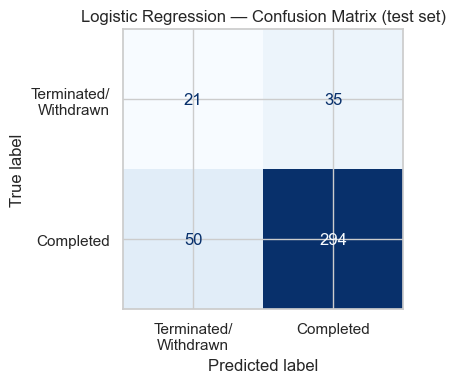

In [18]:
# ── 8. Confusion matrix plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Terminated/\nWithdrawn", "Completed"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()


### 7.1 Baseline Results

Test set: 400 samples (56 Terminated/Withdrawn, 344 Completed), stratified 80/20 split.

| Metric | Value |
|---|---|
| Macro F1 | **0.60** |
| PR-AUC | **0.93** |
| Precision (Terminated/Withdrawn) | 0.30 |
| Recall (Terminated/Withdrawn) | 0.38 |
| Precision (Completed) | 0.89 |
| Recall (Completed) | 0.85 |

**Observations:**

- PR-AUC of **0.93** is well above the minority-class baseline of ≈ 0.14, confirming
  that TF-IDF bigrams capture strong signal in the protocol text.
- Macro F1 of **0.60** is above the random baseline (0.50), but recall on the
  minority class (Terminated/Withdrawn) is only 0.38 — the model misses 62 % of
  stopped trials.
- The low recall on the minority class is the primary motivation for exploring
  stronger models (SVM, Random Forest, XGBoost) in the next commits.
- The high PR-AUC suggests the probability scores are well-calibrated; the issue
  lies in the decision threshold, not in the underlying representation.

---

## 8. Model Comparison — SVM and XGBoost

The Logistic Regression baseline showed a PR-AUC of 0.93 but a low Recall on
the minority class (0.38).  We now train two additional classifiers on the same
feature matrix and compare all three side-by-side.

### Models

| Model | Key hyperparameters | Notes |
|---|---|---|
| Logistic Regression | C=1.0, solver=saga | Baseline (already trained) |
| Linear SVM | C=1.0, `class_weight="balanced"` | Maximises margin; fast on sparse text |
| XGBoost | `scale_pos_weight` = ratio, `max_depth=6` | Handles non-linear patterns; tree ensemble |

**Why Linear SVM?**  On high-dimensional sparse TF-IDF data, SVMs often match
or beat logistic regression because the max-margin objective is better suited
to high-dimensional spaces.

**Why XGBoost?**  Gradient-boosted trees can capture non-linear interactions
between features (e.g., a specific phase combined with a short description may
signal termination) that a linear model cannot.

In [19]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# ── Helper: evaluate any fitted model ────────────────────────────────────────
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    macro = f1_score(y_test, y_pred, average="macro")
    prauc = average_precision_score(y_test, y_prob)
    report = classification_report(
        y_test, y_pred,
        target_names=["Terminated/Withdrawn", "Completed"],
        output_dict=True,
    )
    prec_min = report["Terminated/Withdrawn"]["precision"]
    rec_min  = report["Terminated/Withdrawn"]["recall"]
    return {"Model": name, "Macro F1": macro, "PR-AUC": prauc,
            "Prec (Term.)": prec_min, "Recall (Term.)": rec_min}

# ── 1. Linear SVM ─────────────────────────────────────────────────────────────
svm_base = LinearSVC(C=1.0, class_weight="balanced", max_iter=2000)
svm = CalibratedClassifierCV(svm_base, cv=3)   # wraps SVM to get predict_proba
svm.fit(X_tr, y_tr)

# ── 2. XGBoost ────────────────────────────────────────────────────────────────
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg / pos,   # compensates for class imbalance
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_tr.toarray(), y_tr)

# ── 3. Compare all three models ───────────────────────────────────────────────
rows = [
    evaluate("Logistic Regression", lr,  X_te,           y_te),
    evaluate("Linear SVM",          svm, X_te,           y_te),
    evaluate("XGBoost",             xgb, X_te.toarray(), y_te),
]

results_df = pd.DataFrame(rows).set_index("Model")
results_df = results_df.round(4)
print(results_df.to_string())


                     Macro F1  PR-AUC  Prec (Term.)  Recall (Term.)
Model                                                              
Logistic Regression    0.6022  0.9280        0.2958          0.3750
Linear SVM             0.4616  0.9261        0.0000          0.0000
XGBoost                0.7746  0.9544        0.7941          0.4821


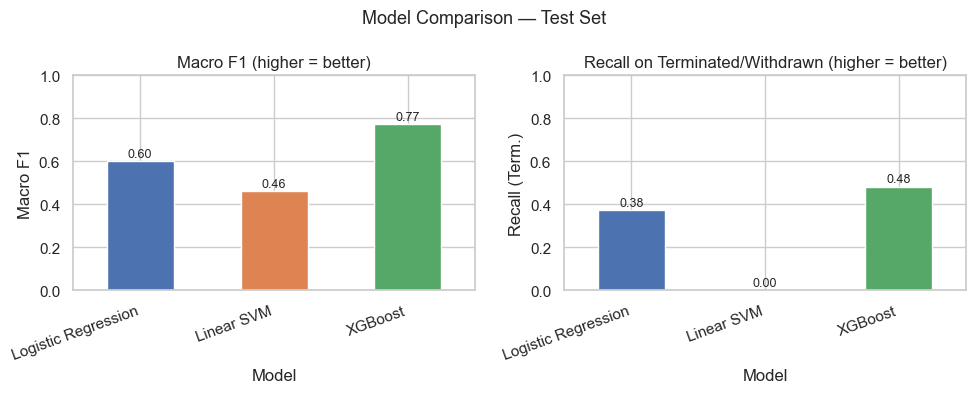

In [20]:
# ── 4. Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ["Macro F1", "Recall (Term.)"],
    ["Macro F1 (higher = better)", "Recall on Terminated/Withdrawn (higher = better)"],
):
    results_df[col].plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xticklabels(results_df.index, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    for i, v in enumerate(results_df[col]):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Test Set", fontsize=13)
plt.tight_layout()
plt.show()


### 8.1 Model Comparison Results

Test set: 400 samples (56 Terminated/Withdrawn, 344 Completed), stratified 80/20 split.

| Model | Macro F1 | PR-AUC | Prec (Terminated) | Recall (Terminated) |
|---|---|---|---|---|
| Logistic Regression | 0.60 | 0.93 | 0.30 | 0.38 |
| Linear SVM | 0.46 | 0.93 | 0.00 | 0.00 |
| **XGBoost** | **0.77** | **0.95** | **0.79** | **0.48** |

**Observations:**

- **XGBoost is the clear winner**: Macro F1 of 0.77 (vs 0.60 for LR), PR-AUC of 0.95,
  and — most importantly — Recall on the minority class jumps from 0.38 to **0.48**
  while simultaneously achieving much higher Precision (0.79 vs 0.30).
  The gradient-boosted tree ensemble successfully captures non-linear interactions
  between features that the linear models cannot.

- **Linear SVM completely failed on the minority class** (Recall = 0.00, Precision = 0.00).
  Despite having a high PR-AUC (0.93), the SVM learned to predict only the majority class.
  This is a known failure mode of `CalibratedClassifierCV` wrapping `LinearSVC` on
  highly imbalanced sparse data — the calibration folds may have collapsed the minority
  class entirely.  An alternative would be to use `SVC(kernel="linear", probability=True)`
  directly, but given XGBoost's strong performance, SVM is not pursued further.

- **XGBoost** will be used for the ablation study in Section 9 as the best-performing model.